In [2]:
import os
import numpy as np

output_dir = "E:/PROKER KKN/shoreline-kemujan/data/output"
years_to_check = [2015, 2020, 2025]
for yr in years_to_check:
    file_path = os.path.join(output_dir, f"Titik_02_{yr}_fase1.npz")
    if os.path.exists(file_path):
        data = np.load(file_path)
        print(f"Tahun {yr} -> X shape: {data['x'].shape} | Y shape: {data['y'].shape}")
    else:
        print(f"File tahun {yr} tidak ditemukan.")

Tahun 2015 -> X shape: (67, 68, 4) | Y shape: (67, 68, 1)
Tahun 2020 -> X shape: (201, 201, 4) | Y shape: (201, 201, 1)
Tahun 2025 -> X shape: (201, 201, 4) | Y shape: (201, 201, 1)


In [3]:
import os
import numpy as np
import cv2

# Path lokal lu
OUTPUT_DIR = "E:/PROKER KKN/shoreline-kemujan/data/output"
TARGET_AOI = "Titik_02"
START_YEAR = 2015
END_YEAR = 2025
TARGET_SHAPE = (128, 128)

X_sequence = []
Y_sequence = []
years_processed = []

print("=== MEMPROSES DATA OFFLINE (NO GEE CALLS) ===")

for yr in range(START_YEAR, END_YEAR + 1):
    # Cari file npz tahunan yang udah lu kelola tadi
    file_name = f"{TARGET_AOI}_{yr}_fase1.npz"
    file_path = os.path.join(OUTPUT_DIR, file_name)
    
    if not os.path.exists(file_path):
        print(f"[SKIP] Tahun {yr} gak ketemu di: {file_path}")
        continue
        
    print(f"Loading & Resizing Tahun {yr}...")
    
    # 1. Load data lokal
    data = np.load(file_path)
    raw_x = data['x']  # shape: (H, W, 4)
    raw_y = data['y']  # shape: (H, W, 1)
    
    # 2. Resize X (RED, GREEN, BLUE, MNDWI) -> INTER_CUBIC biar smooth
    resized_channels = []
    for c in range(raw_x.shape[-1]):
        chan_resized = cv2.resize(raw_x[..., c], TARGET_SHAPE, interpolation=cv2.INTER_CUBIC)
        resized_channels.append(chan_resized)
    arr_x_resized = np.stack(resized_channels, axis=-1)
    
    # 3. Resize Y (Shoreline Edge) -> INTER_NEAREST biar tetep biner (0 atau 1)
    arr_y_resized = cv2.resize(raw_y[..., 0], TARGET_SHAPE, interpolation=cv2.INTER_NEAREST)
    arr_y_resized = np.expand_dims(arr_y_resized, axis=-1)
    
    X_sequence.append(arr_x_resized)
    Y_sequence.append(arr_y_resized)
    years_processed.append(yr)

# 4. Save Final Tensor Stack
if X_sequence:
    X_tensor = np.array(X_sequence)  # Shape: (T, 128, 128, 4)
    Y_tensor = np.array(Y_sequence)  # Shape: (T, 128, 128, 1)
    
    final_path = os.path.join(OUTPUT_DIR, f"{TARGET_AOI}_convlstm_ready.npz")
    np.savez_compressed(final_path, x=X_tensor, y=Y_tensor, years=np.array(years_processed))
    
    print("\n=== PROSES OFFLINE SELESAI ===")
    print(f"Dataset gabungan disimpan di: {final_path}")
    print(f"Final X Shape (Timesteps, H, W, C): {X_tensor.shape}")
    print(f"Final Y Shape (Timesteps, H, W, C): {Y_tensor.shape}")
else:
    print("\n[ERROR] Gak ada file npz yang berhasil diload. Cek path-nya lagi bro!")
    
    
import os
import numpy as np
import cv2

OUTPUT_DIR = "E:/PROKER KKN/shoreline-kemujan/data/output"
TARGET_AOI = "Titik_02"
START_YEAR = 2015
END_YEAR = 2025
TARGET_SHAPE = (128, 128)
LOOKBACK_YEARS = 3  # Jumlah tahun ke belakang untuk input sekuens

X_frames = []
Y_frames = []

print("=== PARSING & SYNCHRONIZING DATA TO BOEN ET AL. SPECIFICATIONS ===")

for yr in range(START_YEAR, END_YEAR + 1):
    file_path = os.path.join(OUTPUT_DIR, f"{TARGET_AOI}_{yr}_fase1.npz")
    if not os.path.exists(file_path):
        continue
        
    data = np.load(file_path)
    raw_x = data['x']  # (H, W, 4) -> Band: RED, GREEN, BLUE, MNDWI
    
    # 1. Resize X
    resized_channels = []
    for c in range(raw_x.shape[-1]):
        chan_resized = cv2.resize(raw_x[..., c], TARGET_SHAPE, interpolation=cv2.INTER_CUBIC)
        resized_channels.append(chan_resized)
    arr_x_resized = np.stack(resized_channels, axis=-1)
    
    # 2. Extract Water Mask dari MNDWI (Channel ke-3) sebagai Target Y
    # Mengikuti standardisasi paper (Dice/IoU tinggi = Segmentasi Area Air/Darat)
    mndwi_channel = arr_x_resized[..., 3]
    water_mask = np.where(mndwi_channel > 0.0, 1.0, 0.0).astype(np.float32)
    arr_y_resized = np.expand_dims(water_mask, axis=-1) # Shape: (128, 128, 1)
    
    X_frames.append(arr_x_resized)
    Y_frames.append(arr_y_resized)

# Konversi ke numpy array deret panjang
X_all = np.array(X_frames)  # (11, 128, 128, 4)
Y_all = np.array(Y_frames)  # (11, 128, 128, 1)

# 3. Proses Slicing Menjadi Sliding Window Dataset
X_samples = []
Y_samples = []

total_years = len(X_all)
for i in range(total_years - LOOKBACK_YEARS):
    # Ambil sekuens input (misal: t0, t1, t2)
    X_samples.append(X_all[i : i + LOOKBACK_YEARS])
    # Ambil target di tahun berikutnya (misal: t3)
    Y_samples.append(Y_all[i + LOOKBACK_YEARS])

X_train = np.array(X_samples)  # Shape akhir: (Samples, Timesteps, H, W, C)
Y_train = np.array(Y_samples)  # Shape akhir: (Samples, H, W, C)

print("\n=== DATA SLICING SELESAI ===")
print(f"Format Input Model ConvLSTM-Net (X): {X_train.shape}")
print(f"Format Target Model (Y): {Y_train.shape}")

=== MEMPROSES DATA OFFLINE (NO GEE CALLS) ===
Loading & Resizing Tahun 2015...
[SKIP] Tahun 2016 gak ketemu di: E:/PROKER KKN/shoreline-kemujan/data/output\Titik_02_2016_fase1.npz
Loading & Resizing Tahun 2017...
Loading & Resizing Tahun 2018...
Loading & Resizing Tahun 2019...
Loading & Resizing Tahun 2020...
Loading & Resizing Tahun 2021...
Loading & Resizing Tahun 2022...
Loading & Resizing Tahun 2023...
Loading & Resizing Tahun 2024...
Loading & Resizing Tahun 2025...

=== PROSES OFFLINE SELESAI ===
Dataset gabungan disimpan di: E:/PROKER KKN/shoreline-kemujan/data/output\Titik_02_convlstm_ready.npz
Final X Shape (Timesteps, H, W, C): (10, 128, 128, 4)
Final Y Shape (Timesteps, H, W, C): (10, 128, 128, 1)
=== PARSING & SYNCHRONIZING DATA TO BOEN ET AL. SPECIFICATIONS ===

=== DATA SLICING SELESAI ===
Format Input Model ConvLSTM-Net (X): (7, 3, 128, 128, 4)
Format Target Model (Y): (7, 128, 128, 1)


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

# Kustom Metrik Dice Coefficient untuk memantau performa sesuai paper
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def build_convlstm_net(img_shape=(128, 128, 4), timesteps=3):
    inputs = layers.Input(shape=(timesteps, img_shape[0], img_shape[1], img_shape[2]))
    
    # --- ENCODER LAYER (Spatiotemporal Feature Extraction) ---
    # Blok 1: ConvLSTM awal -> Resolusi tetap 128x128
    enc1 = layers.ConvLSTM2D(32, (3, 3), padding='same', return_sequences=True, activation='tanh')(inputs)
    enc1_bn = layers.BatchNormalization()(enc1)
    pool1 = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(enc1_bn) # Downsample ke 64x64
    
    # Blok 2: ConvLSTM kedua -> Resolusi menjadi 64x64
    enc2 = layers.ConvLSTM2D(64, (3, 3), padding='same', return_sequences=True, activation='tanh')(pool1)
    enc2_bn = layers.BatchNormalization()(enc2)
    pool2 = layers.TimeDistributed(layers.MaxPooling2D((2, 2)))(enc2_bn) # Downsample ke 32x32
    
    # --- BOTTLENECK ---
    # Mengompresi dimensi waktu (return_sequences=False) untuk memprediksi single-frame target (t+1)
    bottleneck = layers.ConvLSTM2D(128, (3, 3), padding='same', return_sequences=False, activation='tanh')(pool2)
    bottleneck_bn = layers.BatchNormalization()(bottleneck) # Shape: (32, 32, 128)
    
    # --- DECODER LAYER dengan U-Net Skip Connections ---
    # Karena dimensi waktu sudah dikompresi di bottleneck, Decoder menggunakan elemen 2D standar
    
    # Collapse / Ambil frame terakhir dari Encoder untuk Skip Connection agar berdimensi 2D
    skip2 = layers.Lambda(lambda x: x[:, -1, :, :, :])(enc2_bn) # Shape: (64, 64, 64)
    skip1 = layers.Lambda(lambda x: x[:, -1, :, :, :])(enc1_bn) # Shape: (128, 128, 32)
    
    # Up-Blok 1: Resolusi dari 32x32 -> 64x64
    up1 = layers.UpSampling2D((2, 2))(bottleneck_bn)
    concat1 = layers.Concatenate()([up1, skip2])
    dec1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(concat1)
    
    # Up-Blok 2: Resolusi dari 64x64 -> 128x128
    up2 = layers.UpSampling2D((2, 2))(dec1)
    concat2 = layers.Concatenate()([up2, skip1])
    dec2 = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(concat2)
    
    # Output Layer (Binary Segmentation Mask untuk Water/Land)
    outputs = layers.Conv2D(1, (1, 1), padding='same', activation='sigmoid', name='water_mask_output')(dec2)
    
    model = models.Model(inputs, outputs, name="Boen_Et_Al_ConvLSTM_Net")
    
    # Compile Menggunakan Adam + Binary Crossentropy + Metrik Evaluasi Paper
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', dice_coefficient, tf.keras.metrics.OneHotMeanIoU(num_classes=2)]
    )
    
    return model

# Inisialisasi Model
model_convlstm_net = build_convlstm_net(img_shape=(128, 128, 4), timesteps=LOOKBACK_YEARS)
model_convlstm_net.summary()

Model: "Boen_Et_Al_ConvLSTM_Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 3, 128,    │          0 │ -                 │
│ (InputLayer)        │ 128, 4)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d         │ (None, 3, 128,    │     41,600 │ input_layer[0][0] │
│ (ConvLSTM2D)        │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 3, 128,    │        128 │ conv_lstm2d[0][0] │
│ (BatchNormalizatio… │ 128, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 3, 64, 64, │          0 │ batch_normalizat… │
│ (TimeDistributed)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_1       │ (None, 3, 64, 64, │    221,440 │ time_distributed… │
│ (ConvLSTM2D)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3, 64, 64, │        256 │ conv_lstm2d_1[0]… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 3, 32, 32, │          0 │ batch_normalizat… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_lstm2d_2       │ (None, 32, 32,    │    885,248 │ time_distributed… │
│ (ConvLSTM2D)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv_lstm2d_2[0]… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 192)              │            │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │    110,656 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 96)               │            │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     27,680 │ concatenate_1[0]

 Total params: 1,287,553 (4.91 MB)

 Trainable params: 1,287,105 (4.91 MB)

 Non-trainable params: 448 (1.75 KB)

=== DATA SPLIT (KRONOLOGIS) ===
Train Shape: X=(5, 3, 128, 128, 4), Y=(5, 128, 128, 1) (Target 2018-2023)
Test Shape : X=(2, 3, 128, 128, 4), Y=(2, 128, 128, 1) (Target 2024-2025)

=== MEMULAI TRAINING UNTUK Titik_02 ===
Log TensorBoard tersimpan di: E:/PROKER KKN/shoreline-kemujan/data/output\logs\Titik_02\20260715-211341



Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.5250 - dice_coefficient: 0.5886 - loss: 0.6256 - one_hot_mean_io_u: 1.0000

3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6953 - dice_coefficient: 0.7603 - loss: 0.4136 - one_hot_mean_io_u: 1.0000 - val_accuracy: 0.9876 - val_dice_coefficient: 0.5458 - val_loss: 0.6200 - val_one_hot_mean_io_u: 1.0000
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.9912 - dice_coefficient: 0.9843 - loss: 0.0275 - one_hot_mean_io_u: 1.0000

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 724ms/step - accuracy: 0.9908 - dice_coefficient: 0.9847 - loss: 0.0283 - one_hot_mean_io_u: 1.0000 - val_accuracy: 0.9850 - val_dice_coefficient: 0.5812 - val_loss: 0.5688 - val_one_hot_mean_io_u: 1.0000
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.9898 - dice_coefficient: 0.9866 - loss: 0.0283 - one_hot_mean_io_u: 1.0000

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 665ms/step - accuracy: 0.9903 - dice_coefficient: 0.9870 - loss: 0.0261 - one_hot_mean_io_u: 1.0000 - val_accuracy: 0.9867 - val_dice_coefficient: 0.6054 - val_loss: 0.5349 - val_one_hot_mean_io_u: 1.0000
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9909 - dice_coefficient: 0.9865 - loss: 0.0248 - one_hot_mean_io_u: 1.0000

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 727ms/step - accuracy: 0.9972 - dice_coefficient: 0.9955 - loss: 0.0071 - one_hot_mean_io_u: 1.0000 - val_accuracy: 0.9911 - val_dice_coefficient: 0.8858 - val_loss: 0.1285 - val_one_hot_mean_io_u: 1.0000
Epoch 47/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9977 - dice_coefficient: 0.9959 - loss: 0.0061 - one_hot_mean_io_u: 1.0000

3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.9974 - dice_coefficient: 0.9957 - loss: 0.0065 - one_hot_mean_io_u: 1.0000 - val_accuracy: 0.9921 - val_dice_coefficient: 0.8911 - val_loss: 0.1227 - val_one_hot_mean_io_u: 1.0000
Epoch 48/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.9976 - dice_coefficient: 0.9959 - loss: 0.0063 - one_hot_mean_io_u: 1.0000

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 738ms/step - accuracy: 0.9975 - dice_coefficient: 0.9958 - loss: 0.0063 - one_hot_mean_io_u: 1.0000 - val_accuracy: 0.9890 - val_dice_coefficient: 0.8973 - val_loss: 0.1151 - val_one_hot_mean_io_u: 1.0000
Epoch 49/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.9970 - dice_coefficient: 0.9957 - loss: 0.0072 - one_hot_mean_io_u: 1.0000

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 690ms/step - accuracy: 0.9969 - dice_coefficient: 0.9956 - loss: 0.0075 - one_hot_mean_io_u: 1.0000 - val_accuracy: 0.9924 - val_dice_coefficient: 0.9032 - val_loss: 0.1089 - val_one_hot_mean_io_u: 1.0000
Epoch 50/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.9976 - dice_coefficient: 0.9959 - loss: 0.0062 - one_hot_mean_io_u: 1.0000

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 671ms/step - accuracy: 0.9974 - dice_coefficient: 0.9958 - loss: 0.0063 - one_hot_mean_io_u: 1.0000 - val_accuracy: 0.9908 - val_dice_coefficient: 0.9092 - val_loss: 0.1019 - val_one_hot_mean_io_u: 1.0000

=== TRAINING SELESAI! MENAMPILKAN VISUALISASI METRIK ===


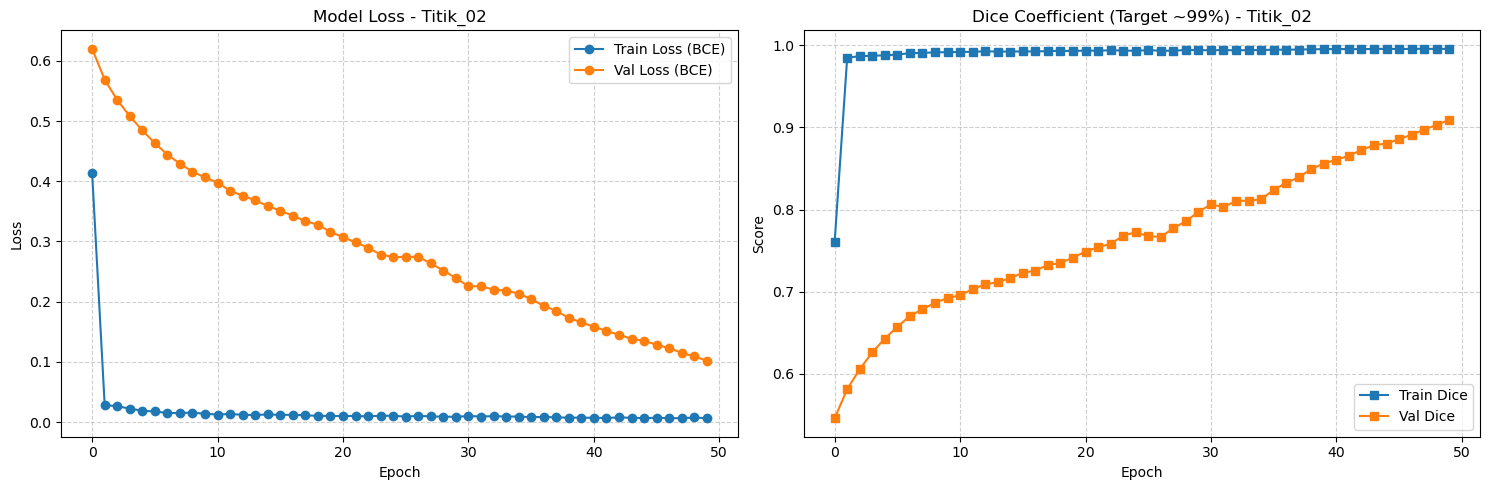

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import datetime
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard

# 1. Chronological Split (Train vs Test)
split_idx = -2 

X_train_split = X_train[:split_idx]
Y_train_split = Y_train[:split_idx]

X_test_split = X_train[split_idx:]
Y_test_split = Y_train[split_idx:]

print("=== DATA SPLIT (KRONOLOGIS) ===")
print(f"Train Shape: X={X_train_split.shape}, Y={Y_train_split.shape} (Target 2018-2023)")
print(f"Test Shape : X={X_test_split.shape}, Y={Y_test_split.shape} (Target 2024-2025)\n")

# 2. Setup Logging & Callbacks
# Bikin folder log khusus buat AOI ini yang ada timestamp-nya
log_dir = os.path.join(OUTPUT_DIR, "logs", TARGET_AOI, datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint(filepath=os.path.join(OUTPUT_DIR, f'best_convlstm_{TARGET_AOI}.h5'), save_best_only=True),
    TensorBoard(log_dir=log_dir, histogram_freq=1, write_graph=True) # Aktifin TensorBoard
]

print(f"=== MEMULAI TRAINING UNTUK {TARGET_AOI} ===")
print(f"Log TensorBoard tersimpan di: {log_dir}\n")

# JALANKAN TENSORBOARD DI DALAM NOTEBOOK
# Hapus tanda pagar (#) di bawah ini kalau lu jalanin di Jupyter/Colab biar UI-nya muncul
%load_ext tensorboard
%tensorboard --logdir "{os.path.join(OUTPUT_DIR, 'logs', TARGET_AOI)}"

# 3. Gas Training!
history = model_convlstm_net.fit(
    X_train_split, Y_train_split,
    validation_data=(X_test_split, Y_test_split),
    epochs=50,          # Bebas dinaikin kalau val_loss masih ada tren turun
    batch_size=2,       
    callbacks=callbacks,
    verbose=1
)

print("\n=== TRAINING SELESAI! MENAMPILKAN VISUALISASI METRIK ===")

# 4. Plot Visualisasi Metrik Akhir (Matplotlib)
plt.figure(figsize=(15, 5))

# A. Plot Loss (Binary Crossentropy)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss (BCE)', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss (BCE)', marker='o')
plt.title(f'Model Loss - {TARGET_AOI}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# B. Plot Dice Coefficient (Akurasi Area Segmentasi)
plt.subplot(1, 2, 2)
# Keras menyimpan nama metrik custom sesuai nama fungsinya, yaitu 'dice_coefficient'
plt.plot(history.history['dice_coefficient'], label='Train Dice', marker='s')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice', marker='s')
plt.title(f'Dice Coefficient (Target ~99%) - {TARGET_AOI}')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

=== MENGEVALUASI MODEL PADA DATA TEST ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


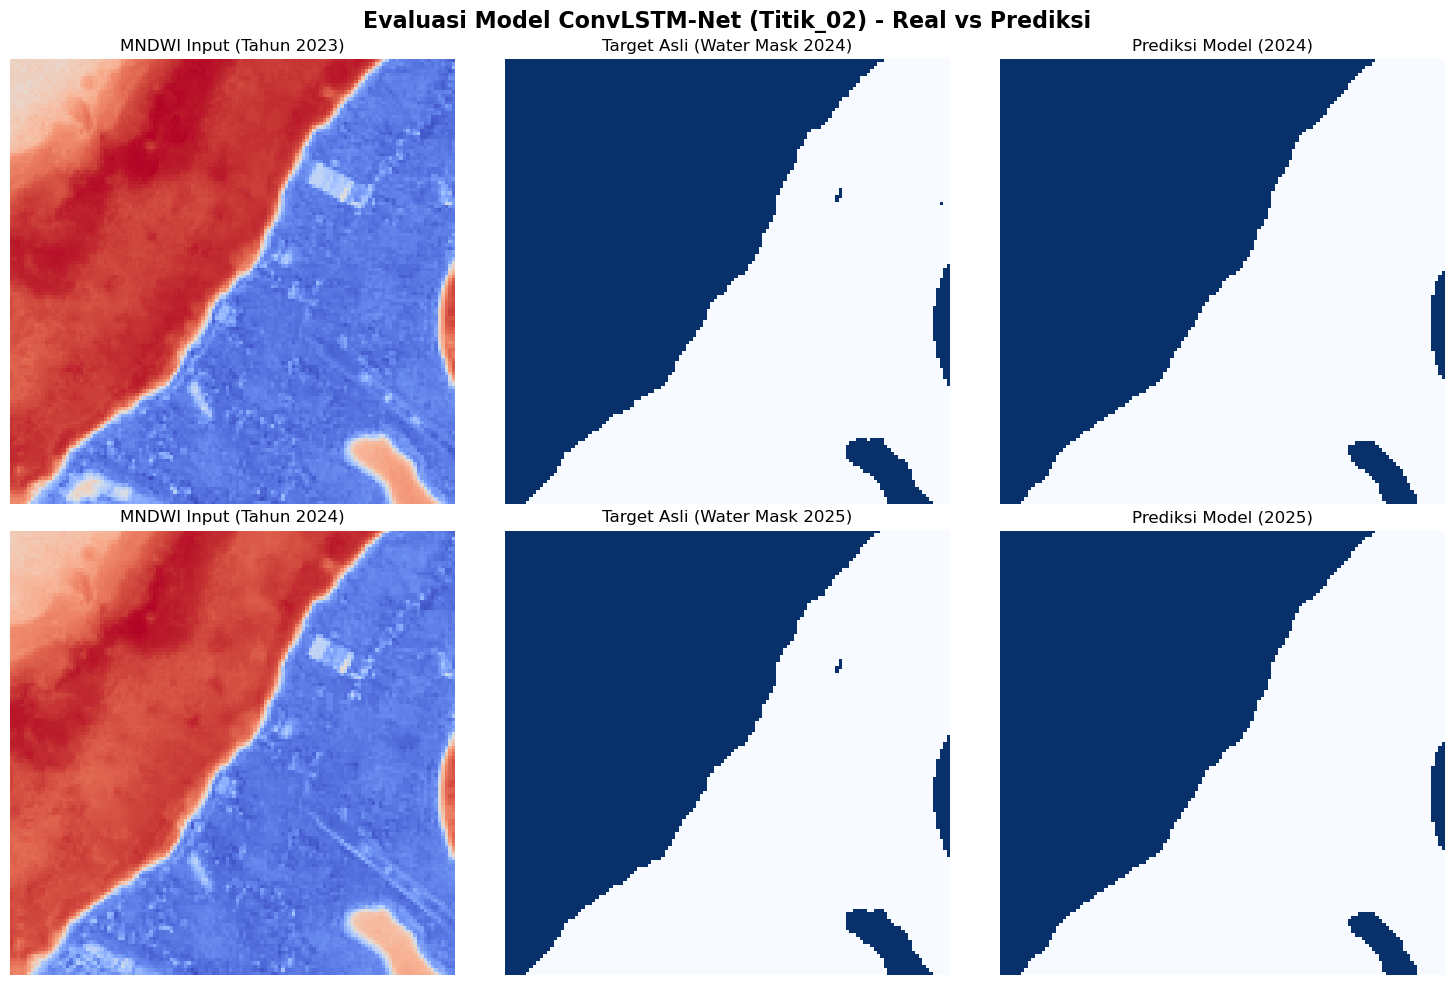


=== MELAKUKAN PROYEKSI MASA DEPAN (2026 - 2028) ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step


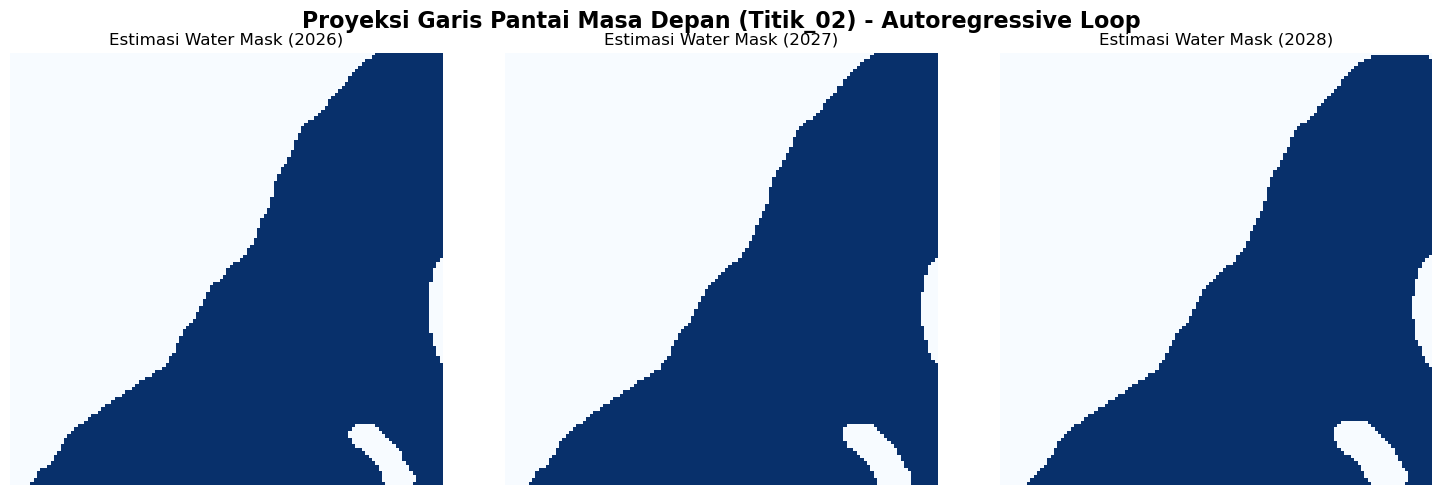

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PART 1: PREDIKSI & EVALUASI DATA TEST (2024 - 2025)
# ==========================================
print("=== MENGEVALUASI MODEL PADA DATA TEST ===")
# Jalankan prediksi pada data test
Y_pred_test = model_convlstm_net.predict(X_test_split)

# Binerisasi hasil prediksi sigmoid (0-1) menjadi mask tegas (0 atau 1)
# Piksel > 0.5 dianggap Air (1.0), sisanya Darat (0.0)
Y_pred_biner = np.where(Y_pred_test > 0.5, 1.0, 0.0)

test_years = [2024, 2025]

# Set up canvas untuk visualisasi evaluasi
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f"Evaluasi Model ConvLSTM-Net ({TARGET_AOI}) - Real vs Prediksi", fontsize=16, fontweight='bold')

for i in range(2):
    # Kolom 1: MNDWI tahun sebelumnya (sebagai referensi input terakhir)
    ax1 = axes[i, 0]
    # Indeks 3 adalah channel MNDWI
    ax1.imshow(X_test_split[i, -1, ..., 3], cmap='coolwarm') 
    ax1.set_title(f"MNDWI Input (Tahun {test_years[i]-1})", fontsize=12)
    ax1.axis('off')
    
    # Kolom 2: Ground Truth (Water Mask Sebenarnya)
    ax2 = axes[i, 1]
    ax2.imshow(Y_test_split[i, ..., 0], cmap='Blues')
    ax2.set_title(f"Target Asli (Water Mask {test_years[i]})", fontsize=12)
    ax2.axis('off')
    
    # Kolom 3: Hasil Prediksi Model
    ax3 = axes[i, 2]
    ax3.imshow(Y_pred_biner[i, ..., 0], cmap='Blues')
    ax3.set_title(f"Prediksi Model ({test_years[i]})", fontsize=12)
    ax3.axis('off')

plt.tight_layout()
plt.show()


# ==========================================
# PART 2: FORECASTING MASA DEPAN (2026 - 2028)
# ==========================================
print("\n=== MELAKUKAN PROYEKSI MASA DEPAN (2026 - 2028) ===")

future_years = [2026, 2027, 2028]
future_predictions = []

# Ambil sekuens 3 tahun terakhir dari data asli (2023, 2024, 2025) sebagai modal awal
current_sequence = X_all[-3:].copy() 

for year in future_years:
    # 1. Prediksi frame tahun berikutnya (tambahkan dimensi batch di depan)
    pred_prob = model_convlstm_net.predict(np.expand_dims(current_sequence, axis=0))[0]
    pred_mask = np.where(pred_prob > 0.5, 1.0, 0.0) # Jadikan biner 0 atau 1
    future_predictions.append(pred_mask)
    
    # 2. Rekonstruksi frame baru untuk sliding window berikutnya
    # Ambil background RGB dari tahun terakhir (2025) agar konstan
    last_rgb = current_sequence[-1, ..., :3]  # Shape: (128, 128, 3)
    
    # Tempelkan hasil prediksi water mask sebagai channel ke-4 (pengganti MNDWI)
    new_frame = np.concatenate([last_rgb, pred_mask], axis=-1) # Shape: (128, 128, 4)
    
    # 3. Geser window: Buang tahun tertua (indeks 0), masukkan frame hasil prediksi baru di akhir
    current_sequence = np.concatenate([current_sequence[1:], np.expand_dims(new_frame, axis=0)], axis=0)

# Set up canvas untuk visualisasi masa depan
fig_future, axes_future = plt.subplots(1, 3, figsize=(15, 5))
fig_future.suptitle(f"Proyeksi Garis Pantai Masa Depan ({TARGET_AOI}) - Autoregressive Loop", fontsize=16, fontweight='bold')

for i, year in enumerate(future_years):
    ax = axes_future[i]
    ax.imshow(future_predictions[i][..., 0], cmap='Blues_r') # Blues_r biar kontras darat-lautnya enak dilihat
    ax.set_title(f"Estimasi Water Mask ({year})", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

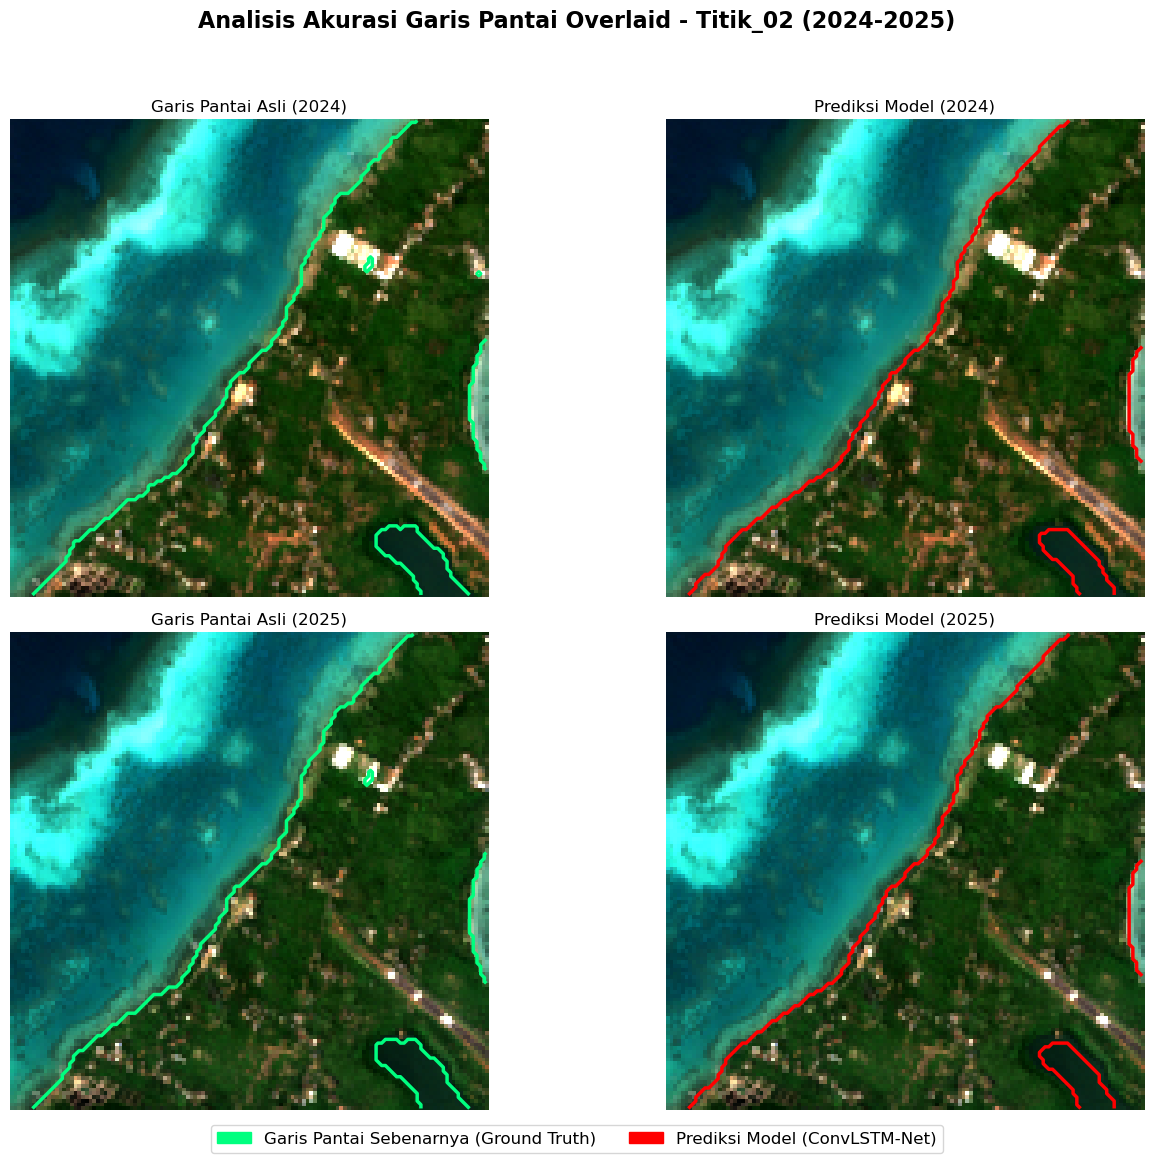

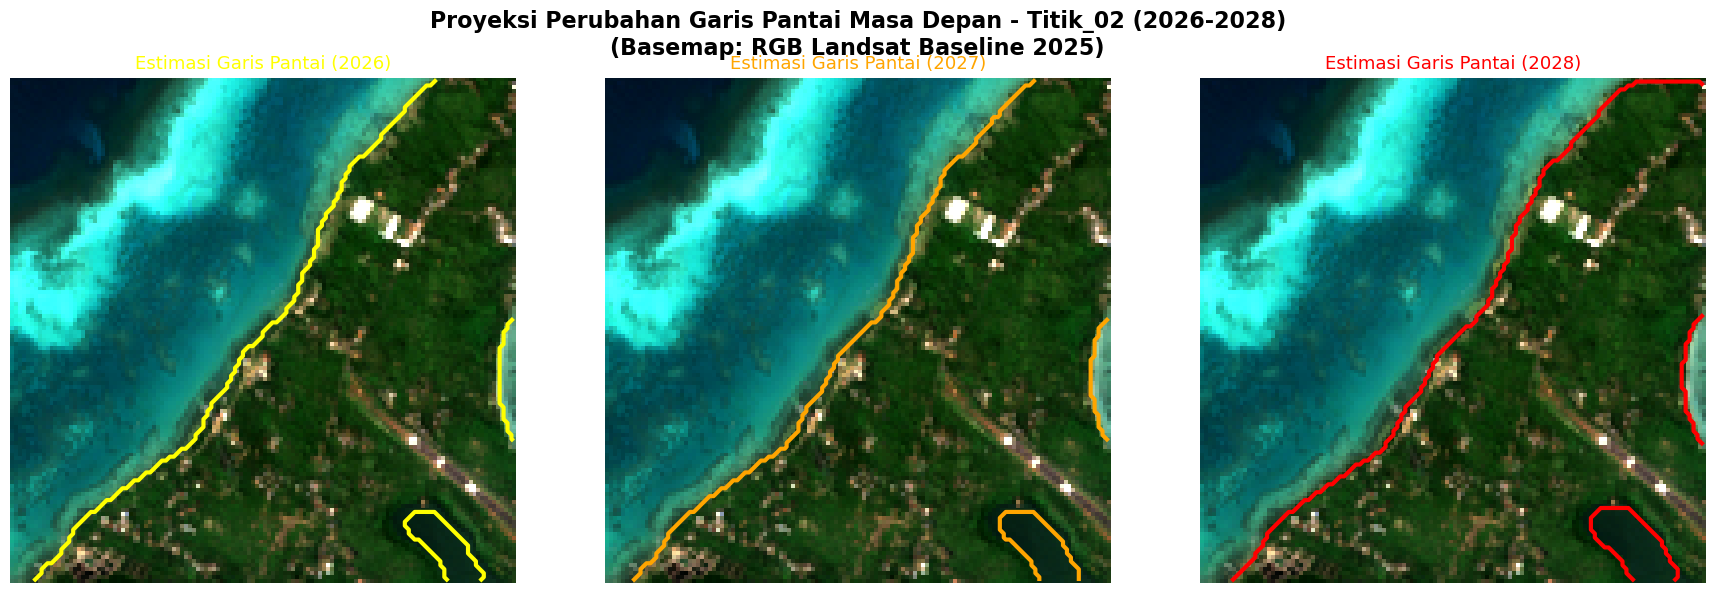

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Helper Function untuk Normalisasi RGB
def scale_rgb(rgb_img):
    # Clip outlier piksel ekstrem (persentil 2% s.d. 98%) biar kontrasnya tajam
    p2, p98 = np.percentile(rgb_img, (2, 98))
    clipped = np.clip(rgb_img, p2, p98)
    # Penskalaan normal ke range 0-1 agar terbaca imshow
    denom = clipped.max() - clipped.min()
    if denom == 0:
        return np.zeros_like(clipped)
    return (clipped - clipped.min()) / denom

# 2. Ambil Basemap RGB Asli dari Data Mentah (Channel 0, 1, 2)
# Pakai indeks negatif biar aman dari error out of bounds!
rgb_2024 = scale_rgb(X_all[-2, ..., :3]) # -2 artinya data kedua teranyar (2024)
rgb_2025 = scale_rgb(X_all[-1, ..., :3]) # -1 artinya data paling terakhir (2025)

# =====================================================================
# PLOT A: EVALUASI HISTORIS OVERLAY (2024 & 2025)
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle(f"Analisis Akurasi Garis Pantai Overlaid - {TARGET_AOI} (2024-2025)", fontsize=16, fontweight='bold')

# --- TAHUN 2024 ---
# Kolom Kiri: Garis Pantai Sebenarnya (Hijau)
axes[0, 0].imshow(rgb_2024)
axes[0, 0].contour(Y_test_split[0, ..., 0], levels=[0.5], colors='springgreen', linewidths=2.5)
axes[0, 0].set_title("Garis Pantai Asli (2024)", fontsize=12)
axes[0, 0].axis('off')

# Kolom Kanan: Hasil Prediksi Model (Merah)
axes[0, 1].imshow(rgb_2024)
axes[0, 1].contour(Y_pred_biner[0, ..., 0], levels=[0.5], colors='red', linewidths=2.5)
axes[0, 1].set_title("Prediksi Model (2024)", fontsize=12)
axes[0, 1].axis('off')

# --- TAHUN 2025 ---
# Kolom Kiri: Garis Pantai Sebenarnya (Hijau)
axes[1, 0].imshow(rgb_2025)
axes[1, 0].contour(Y_test_split[1, ..., 0], levels=[0.5], colors='springgreen', linewidths=2.5)
axes[1, 0].set_title("Garis Pantai Asli (2025)", fontsize=12)
axes[1, 0].axis('off')

# Kolom Kanan: Hasil Prediksi Model (Merah)
axes[1, 1].imshow(rgb_2025)
axes[1, 1].contour(Y_pred_biner[1, ..., 0], levels=[0.5], colors='red', linewidths=2.5)
axes[1, 1].set_title("Prediksi Model (2025)", fontsize=12)
axes[1, 1].axis('off')

# Tambahkan legenda di bawah grafik
green_patch = mpatches.Patch(color='springgreen', label='Garis Pantai Sebenarnya (Ground Truth)')
red_patch = mpatches.Patch(color='red', label='Prediksi Model (ConvLSTM-Net)')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=12, bbox_to_anchor=(0.5, 0.02))

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


# =====================================================================
# PLOT B: PROYEKSI DETEKSI MASA DEPAN OVERLAY (2026 - 2028)
# =====================================================================
fig_future, axes_future = plt.subplots(1, 3, figsize=(18, 6))
fig_future.suptitle(f"Proyeksi Perubahan Garis Pantai Masa Depan - {TARGET_AOI} (2026-2028)\n(Basemap: RGB Landsat Baseline 2025)", fontsize=16, fontweight='bold')

# Gradasi warna masa depan: Kuning (2026) -> Oranye (2027) -> Merah (2028)
colors_list = ['yellow', 'orange', 'red'] 

for i, year in enumerate(future_years):
    ax = axes_future[i]
    # Render basemap citra satelit tahun terakhir yang valid (2025)
    ax.imshow(rgb_2025)
    
    # Overlay kontur garis pantai masa depan hasil autoregressive loop
    ax.contour(future_predictions[i][..., 0], levels=[0.5], colors=colors_list[i], linewidths=3.0)
    
    ax.set_title(f"Estimasi Garis Pantai ({year})", fontsize=13, color=colors_list[i])
    ax.axis('off')

plt.tight_layout()
plt.show()

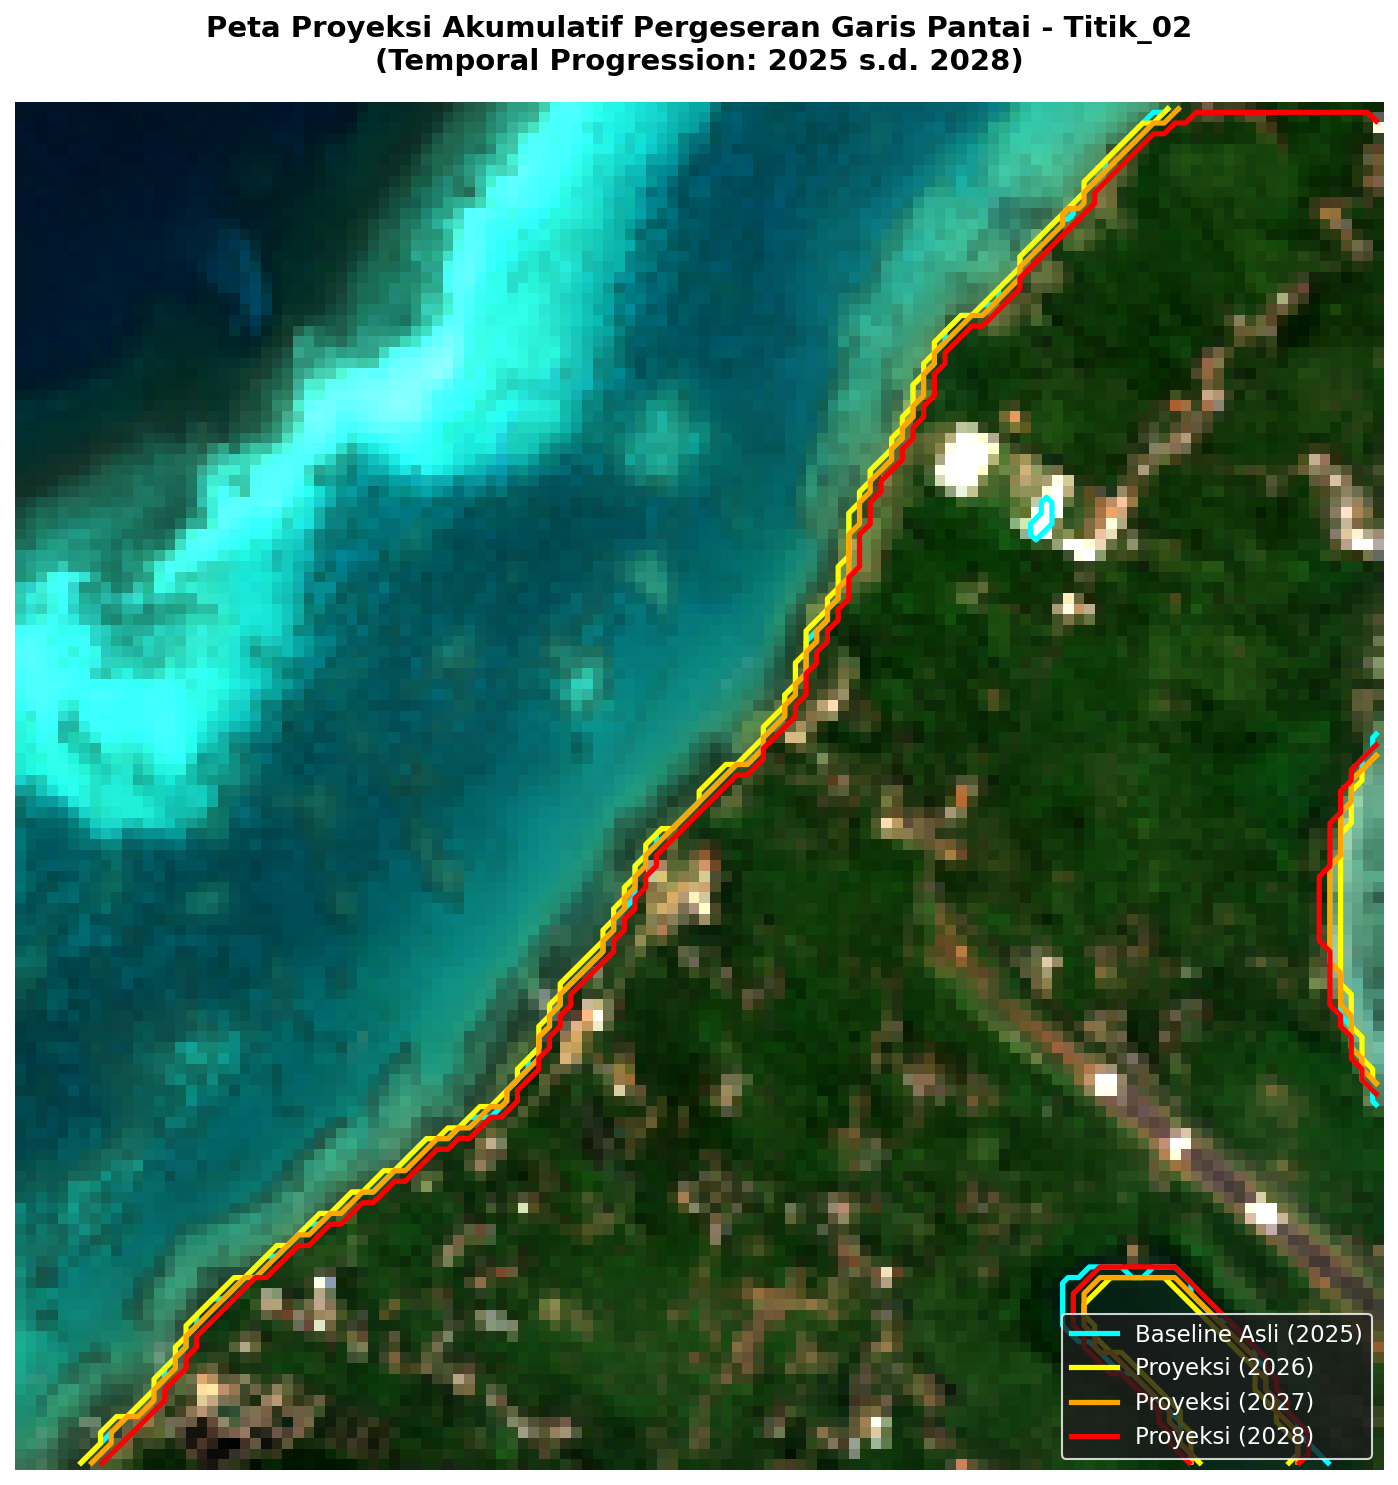

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# 1. Pastikan helper scale_rgb sudah terdefinisi (gw tulis lagi biar aman & standalone)
def scale_rgb(rgb_img):
    p2, p98 = np.percentile(rgb_img, (2, 98))
    clipped = np.clip(rgb_img, p2, p98)
    denom = clipped.max() - clipped.min()
    if denom == 0:
        return np.zeros_like(clipped)
    return (clipped - clipped.min()) / denom

# 2. Ambil Basemap RGB Landsat 2025
rgb_2025 = scale_rgb(X_all[-1, ..., :3])

# 3. Setup Kanvas Peta Tunggal
plt.figure(figsize=(10, 10), dpi=150) # DPI agak tinggi biar konturnya tajem
plt.imshow(rgb_2025)

# --- OVERLAY GARIS PANTAI (CONTOUR MULTI-YEAR) ---

# A. Baseline Tahun 2025 (Asli) - Warna Cyan (Biru Muda terang)
# Y_test_split[1] adalah target asli tahun 2025
plt.contour(Y_test_split[1, ..., 0], levels=[0.5], colors='cyan', linewidths=2.5)

# B. Proyeksi Tahun 2026, 2027, 2028 (Prediksi) - Gradasi Kuning ke Merah
colors_future = ['yellow', 'orange', 'red']
future_years = [2026, 2027, 2028]

for i, year in enumerate(future_years):
    plt.contour(future_predictions[i][..., 0], levels=[0.5], colors=colors_future[i], linewidths=2.5)

# --- SETUP LEGENDA & JUDUL ---

# Bikin penanda garis manual buat ditaruh di box legenda
legend_lines = [
    mlines.Line2D([], [], color='cyan', linewidth=2.5, label='Baseline Asli (2025)'),
    mlines.Line2D([], [], color='yellow', linewidth=2.5, label='Proyeksi (2026)'),
    mlines.Line2D([], [], color='orange', linewidth=2.5, label='Proyeksi (2027)'),
    mlines.Line2D([], [], color='red', linewidth=2.5, label='Proyeksi (2028)')
]

# Tempatkan legenda di pojok kanan bawah (dengan background gelap biar kebaca)
plt.legend(
    handles=legend_lines, 
    loc='lower right', 
    fontsize=11, 
    facecolor='#1c1c1c', 
    edgecolor='white', 
    labelcolor='white'
)

plt.title(
    f"Peta Proyeksi Akumulatif Pergeseran Garis Pantai - {TARGET_AOI}\n(Temporal Progression: 2025 s.d. 2028)", 
    fontsize=14, 
    fontweight='bold', 
    pad=15
)

plt.axis('off')
plt.tight_layout()
plt.show()